In [37]:
import os
import re
import csv
import numpy as np
import pandas as pd
import mendeleev as md
from math import gcd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/7_prediction'
if not os.path.exists(root):
    root = '/Users/hailey/Desktop/3_RuO2/7_prediction'
# root = '/Users/hailey/Desktop/3_RuO2/6_ICOHP/4_slab_M-RuO2'
# oxygen_potential = -4.658724749999999 # 300K
oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
# oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (8, 6)
dpi = 300

In [38]:
element_indices = list(range(21, 31)) + list(range(39, 49)) + [57] + list(range(72, 81))
elements = [md.element(i).symbol for i in element_indices]
data = pd.DataFrame(index=elements)
data['a'] = element_indices

In [39]:
# os: oxidation state
for i in element_indices:
    element = md.element(i).symbol
    for dir in ['0_M', '1_MxOy', '2_MO2', '3_M-RuO2']:
        oxide_type = dir.split('_')[1]
        path = os.path.join(root, '1_bulk_opt', dir, f'{i}_{element}')
        energy_file = os.path.join(path, 'final_with_calculator.json')
        moment_file = os.path.join(path, 'moments.json')
        charge_file = os.path.join(path, 'atoms_bader_charge.json')
        row_updates = {}
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            metal_indices = [i for i, atom in enumerate(atoms) if atom.symbol in elements]
            n_atoms = len(atoms)
            n_oxygens = sum(atom.symbol == 'O' for atom in atoms)
            n_metals = sum(atom.symbol != 'O' for atom in atoms)
            oxidation_state = 2 * n_oxygens / n_metals
            energy = atoms.get_potential_energy() / n_metals
            row_updates[f'{oxide_type}_e'] = energy
            if oxide_type == 'MxOy':
                common_divisor = gcd(n_metals, n_oxygens)
                m_ratio = n_metals // common_divisor
                o_ratio = n_oxygens // common_divisor
                row_updates['MxOy_x'] = m_ratio
                row_updates['MxOy_y'] = o_ratio
                row_updates['MxOy_os'] = oxidation_state
        if os.path.exists(moment_file):
            atoms = read(moment_file)
            moments = atoms.get_magnetic_moments()
            if oxide_type == 'M-RuO2':
                row_updates['M-RuO2_m'] = np.mean(np.abs(moments[0:7]))
                for i, moment in enumerate(moments[metal_indices]):
                    row_updates[f'M-RuO2_m{i}'] = moment
            else:
                row_updates[f'{oxide_type}_m'] = np.mean(np.abs(moments[metal_indices]))
        if os.path.exists(charge_file):
            atoms = read(charge_file)
            charges = atoms.get_initial_charges()
            if oxide_type == 'M-RuO2':
                row_updates['M-RuO2_c'] = np.mean(np.abs(charges[0:7]))
                for i, charge in enumerate(charges):
                    row_updates[f'M-RuO2_c{i}'] = charge
            else:
                row_updates[f'{oxide_type}_c'] = np.mean(np.abs(charges[metal_indices]))
        if row_updates:
            data.loc[element, list(row_updates)] = list(row_updates.values())

# de: doping energy
# fe: formation energy
# data['M-RuO2_de'] = data['M-RuO2_e'] - 7/8*data['MO2_e']['Ru'] - 1/8*data['MO2_e']
data['M-RuO2_fe1'] = data['M-RuO2_e'] - 7/8*data['M_e']['Ru'] - 1/8*data['M_e'] - 2*oxygen_potential
data['M-RuO2_fe2'] = data['M-RuO2_e'] - 7/8*data['MO2_e']['Ru'] - 1/8*data['MO2_e']
data['M-RuO2_fe3'] = data['M-RuO2_e'] - 7/8*data['MxOy_e']['Ru'] - 1/8*data['MxOy_e'] - (2-data['MxOy_y']/data['MxOy_x'])/8*oxygen_potential
# data['MxOy_fe'] = data['MxOy_e'] - data['MO2_e'] - (2-data['MxOy_y']/data['MxOy_x'])*oxygen_potential
data.drop(columns=['MO2_e', 'MxOy_e', 'M-RuO2_e'], inplace=True)
data.loc['Nb', 'MxOy_x'] = 2
data.loc['Nb', 'MxOy_y'] = 5
data


,a,M_e,M_m,M_c,MxOy_x,MxOy_y,MxOy_os,MxOy_m,MxOy_c,MO2_m,MO2_c,M-RuO2_m,M-RuO2_m0,M-RuO2_m1,M-RuO2_m2,M-RuO2_m3,M-RuO2_m4,M-RuO2_m5,M-RuO2_m6,M-RuO2_m7,M-RuO2_c,M-RuO2_c0,M-RuO2_c1,M-RuO2_c2,M-RuO2_c3,M-RuO2_c4,M-RuO2_c5,M-RuO2_c6,M-RuO2_c7,M-RuO2_c8,M-RuO2_c9,M-RuO2_c10,M-RuO2_c11,M-RuO2_c12,M-RuO2_c13,M-RuO2_c14,M-RuO2_c15,M-RuO2_c16,M-RuO2_c17,M-RuO2_c18,M-RuO2_c19,M-RuO2_c20,M-RuO2_c21,M-RuO2_c22,M-RuO2_c23,M-RuO2_fe1,M-RuO2_fe2,M-RuO2_fe3
Sc,21,-6.25,0.00,0.00,2.00,3.00,3.00,0.00,2.02,0.00,2.00,1.47,1.39,1.39,1.56,1.56,-1.40,-1.41,-1.58,0.03,1.74,1.71,1.71,1.74,1.74,1.73,1.75,1.80,2.02,-0.93,-0.93,-0.87,-0.87,-0.93,-0.93,-0.87,-0.87,-0.85,-0.89,-0.87,-0.89,-0.85,-0.89,-0.87,-0.89,-1.42,-0.14,0.05
Ti,22,-7.78,0.00,0.31,1.00,2.00,4.00,0.00,1.99,0.00,1.99,1.40,1.41,1.41,1.43,1.43,-1.37,-1.38,-1.38,0.07,1.74,1.75,1.75,1.75,1.74,1.74,1.74,1.72,1.99,-0.92,-0.92,-0.87,-0.87,-0.92,-0.92,-0.87,-0.87,-0.87,-0.88,-0.88,-0.89,-0.87,-0.88,-0.88,-0.89,-1.08,0.04,0.04
V,23,-8.95,0.00,0.00,2.00,3.00,3.00,2.00,1.75,1.06,1.95,1.39,1.40,1.40,1.42,1.42,-1.35,-1.36,-1.39,-1.06,1.75,1.76,1.76,1.75,1.75,1.75,1.74,1.73,1.97,-0.92,-0.92,-0.87,-0.87,-0.92,-0.92,-0.87,-0.87,-0.87,-0.87,-0.87,-0.92,-0.87,-0.87,-0.87,-0.92,-0.82,0.01,-0.05
Cr,24,-9.49,0.00,0.00,2.00,3.00,3.00,3.06,1.67,2.12,1.85,1.35,1.30,1.30,1.40,1.40,-1.34,-1.33,-1.35,-2.90,1.76,1.75,1.75,1.77,1.77,1.75,1.75,1.76,1.79,-0.90,-0.90,-0.87,-0.87,-0.90,-0.90,-0.87,-0.87,-0.86,-0.86,-0.87,-0.91,-0.87,-0.87,-0.87,-0.91,-0.71,-0.04,0.01
Mn,25,-8.98,0.00,0.06,3.00,4.00,2.67,4.17,1.57,2.98,1.87,1.37,1.23,1.23,1.43,1.43,-1.36,-1.35,-1.56,-3.92,1.76,1.72,1.72,1.76,1.76,1.75,1.75,1.83,1.72,-0.88,-0.88,-0.87,-0.87,-0.88,-0.88,-0.87,-0.87,-0.86,-0.87,-0.86,-0.92,-0.86,-0.87,-0.86,-0.92,-0.65,-0.02,-0.02
Fe,26,-8.24,2.19,0.00,2.00,3.00,3.00,4.35,1.76,3.71,1.72,1.38,1.29,1.29,1.49,1.49,-1.37,-1.37,-1.32,-4.17,1.75,1.75,1.75,1.76,1.76,1.74,1.75,1.74,1.68,-0.90,-0.90,-0.87,-0.87,-0.90,-0.90,-0.87,-0.87,-0.87,-0.87,-0.86,-0.83,-0.87,-0.87,-0.86,-0.83,-0.52,-0.09,-0.02
Co,27,-7.04,1.59,0.00,3.00,4.00,2.67,2.11,1.37,0.75,1.51,1.38,1.23,1.23,1.49,1.49,-1.34,-1.34,-1.55,-2.32,1.76,1.73,1.73,1.78,1.78,1.75,1.75,1.83,1.42,-0.85,-0.85,-0.87,-0.87,-0.85,-0.85,-0.87,-0.87,-0.86,-0.86,-0.86,-0.87,-0.86,-0.86,-0.86,-0.87,-0.42,-0.05,-0.00
Ni,28,-5.47,0.61,0.00,1.00,1.00,2.00,1.83,1.22,0.00,1.38,1.47,1.27,1.27,1.59,1.59,-1.38,-1.38,-1.83,-1.76,1.78,1.74,1.74,1.80,1.80,1.74,1.75,1.91,1.29,-0.86,-0.86,-0.87,-0.87,-0.86,-0.86,-0.87,-0.87,-0.86,-0.87,-0.87,-0.83,-0.86,-0.87,-0.87,-0.83,-0.33,-0.22,0.00
Cu,29,-3.73,0.00,0.00,1.00,1.00,2.00,0.76,1.09,0.70,1.32,1.38,1.17,1.17,1.39,1.39,-1.37,-1.37,-1.78,-0.84,1.75,1.71,1.71,1.70,1.70,1.75,1.75,1.90,1.28,-0.82,-0.82,-0.86,-0.86,-0.82,-0.82,-0.86,-0.86,-0.85,-0.86,-0.84,-0.83,-0.85,-0.86,-0.84,-0.83,-0.19,-0.23,0.04
Zn,30,-1.11,0.00,0.01,1.00,1.00,2.00,0.00,1.17,0.00,1.43,1.46,1.26,1.26,1.57,1.57,-1.39,-1.39,-1.75,0.02,1.77,1.71,1.71,1.78,1.78,1.74,1.75,1.89,1.32,-0.86,-0.86,-0.87,-0.87,-0.86,-0.86,-0.87,-0.87,-0.85,-0.87,-0.87,-0.80,-0.85,-0.87,-0.87,-0.80,-0.68,-0.25,0.05


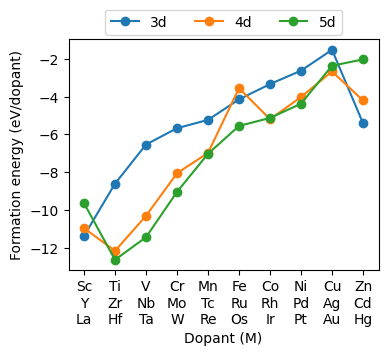

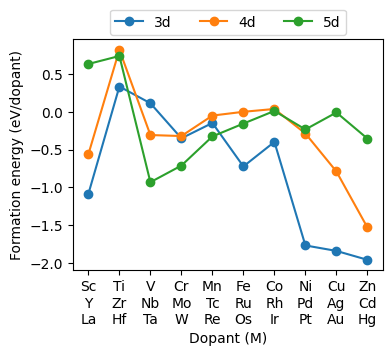

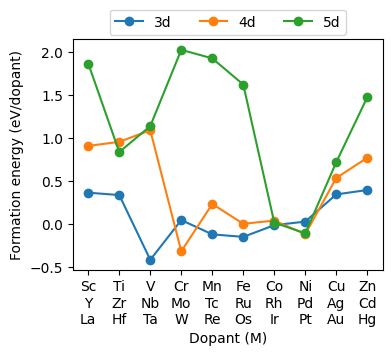

In [40]:

colors = ['tab:blue', 'tab:orange', 'tab:green']

n = len(data)
chunk = 10
slices = [(0, chunk), (chunk, 2 * chunk), (2 * chunk, n)]
row_suffix = ['3d', '4d', '5d']
x = np.arange(1, chunk + 1)
xtick_labels = []
for i in range(chunk):
    xtick_labels.append(
        '\n'.join(
            str(data.index[lo + i])
            for lo, hi in slices
            if lo + i < min(hi, n)
        )
    )

for c, col in enumerate(['M-RuO2_fe1', 'M-RuO2_fe2', 'M-RuO2_fe3']):
    plt.figure(figsize=(4,3))

    for si, (lo, hi) in enumerate(slices):
        if lo >= n:
            break
        hi = min(hi, n)
        y = (data[col].iloc[lo:hi]*8).to_numpy() # per dopant
        plt.plot(
            x[: len(y)],
            y,
            marker='o',
            linestyle='-',
            label=f'{row_suffix[si]}',
            color=colors[si % len(colors)],
        )

    plt.xlim(0.5, chunk + 0.5)
    plt.legend(bbox_to_anchor=(0.5, 1.02), loc='lower center', borderaxespad=0, ncol=3)
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xticks(x, xtick_labels)

    plt.xlabel('Dopant (M)')
    plt.ylabel('Formation energy (eV/dopant)')
    plt.savefig(f'{root}/figures/bulk_formation_energy{c}.png', dpi=dpi, transparent=True, bbox_inches='tight')

    plt.show()
    plt.close()

    # Co Ni Cu
    # Co Ni Cu

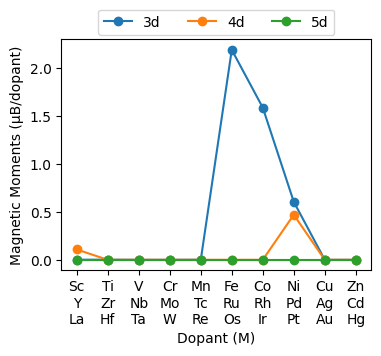

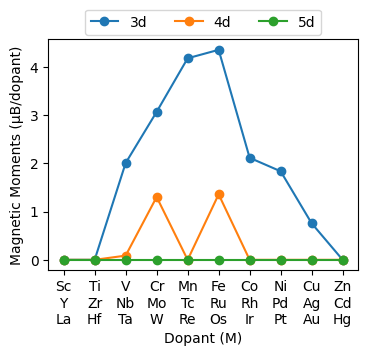

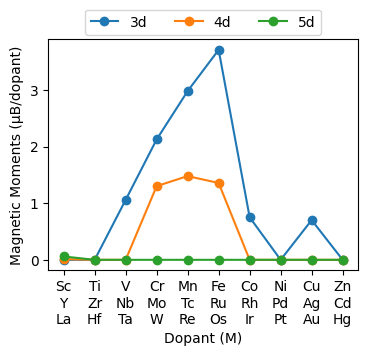

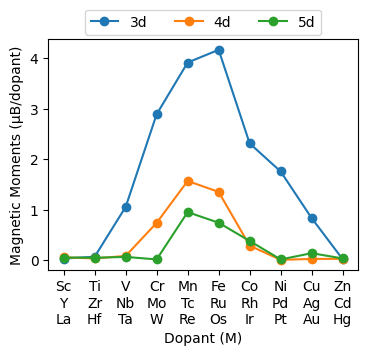

In [41]:
for c, col in enumerate(['M_m', 'MxOy_m', 'MO2_m', 'M-RuO2_m7']):
    plt.figure(figsize=(4,3))

    for si, (lo, hi) in enumerate(slices):
        if lo >= n:
            break
        hi = min(hi, n)
        y = (np.abs(data[col].iloc[lo:hi])).to_numpy() # per dopant
        plt.plot(
            x[: len(y)],
            y,
            marker='o',
            linestyle='-',
            label=f'{row_suffix[si]}',
            color=colors[si % len(colors)],
        )

    plt.xlim(0.5, chunk + 0.5)
    plt.legend(bbox_to_anchor=(0.5, 1.02), loc='lower center', borderaxespad=0, ncol=3)
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xticks(x, xtick_labels)

    plt.xlabel('Dopant (M)')
    plt.ylabel('Magnetic Moments (μB/dopant)')
    plt.savefig(f'{root}/figures/bulk_magnetic_moment{c}.png', dpi=dpi, transparent=True, bbox_inches='tight')

    plt.show()
    plt.close()

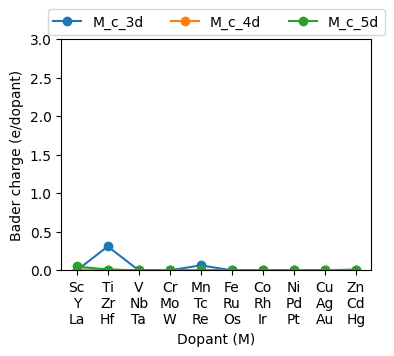

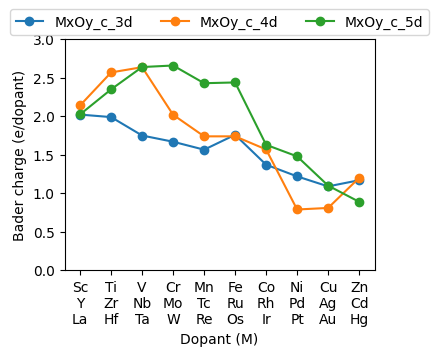

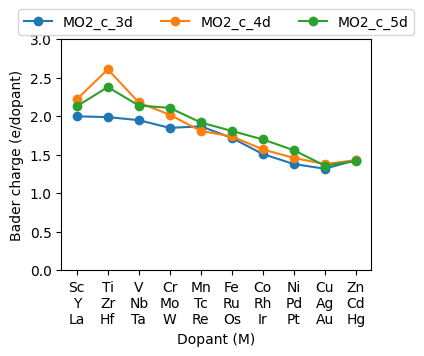

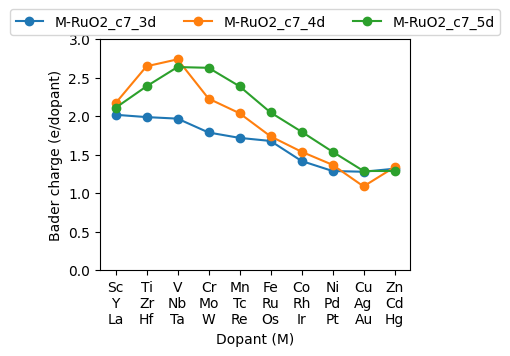

In [42]:
for c, col in enumerate(['M_c', 'MxOy_c', 'MO2_c', 'M-RuO2_c7']):
    plt.figure(figsize=(4,3))

    for si, (lo, hi) in enumerate(slices):
        if lo >= n:
            break
        hi = min(hi, n)
        y = (np.abs(data[col].iloc[lo:hi])).to_numpy() # per dopant
        plt.plot(
            x[: len(y)],
            y,
            marker='o',
            linestyle='-',
            label=f'{col}_{row_suffix[si]}',
            color=colors[si % len(colors)],
        )

    plt.xlim(0.5, chunk + 0.5)
    plt.ylim(0.0, 3.0)
    plt.legend(bbox_to_anchor=(0.5, 1.02), loc='lower center', borderaxespad=0, ncol=3)
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xticks(x, xtick_labels)

    plt.xlabel('Dopant (M)')
    plt.ylabel('Bader charge (e/dopant)')
    plt.savefig(f'{root}/figures/bulk_bader_charge{c}.png', dpi=dpi, transparent=True, bbox_inches='tight')

    plt.show()
    plt.close()

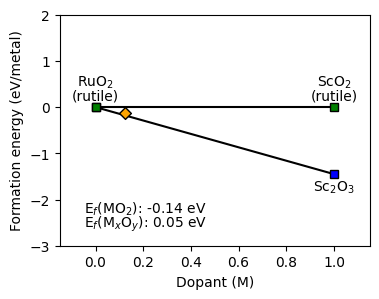

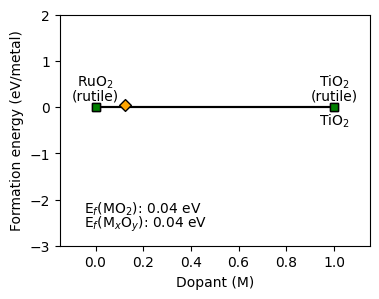

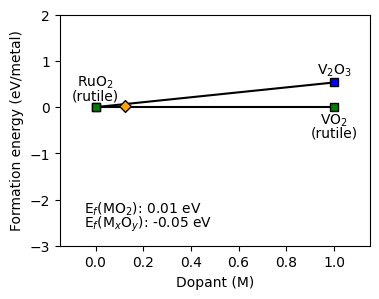

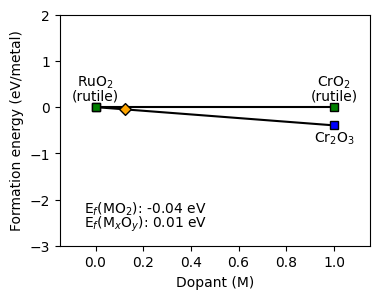

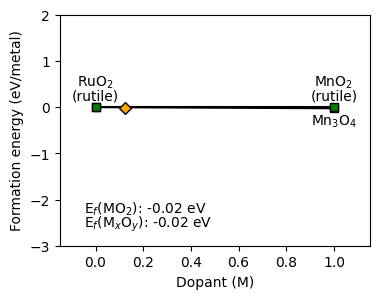

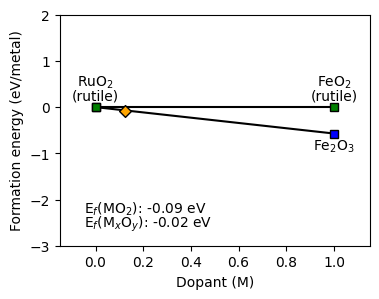

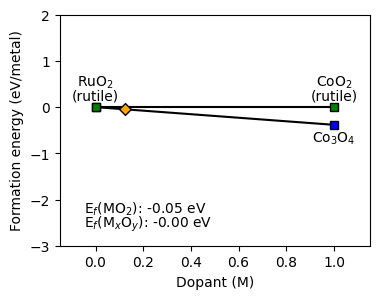

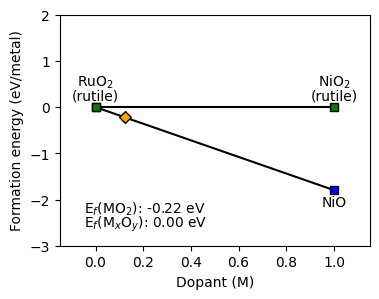

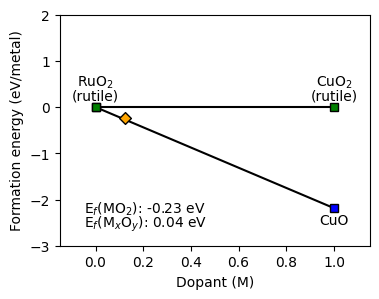

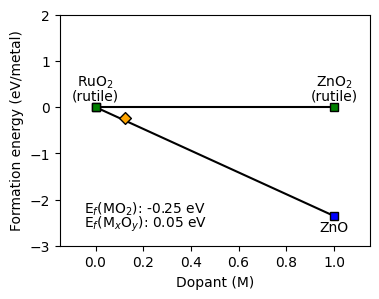

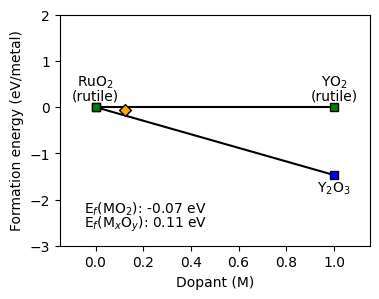

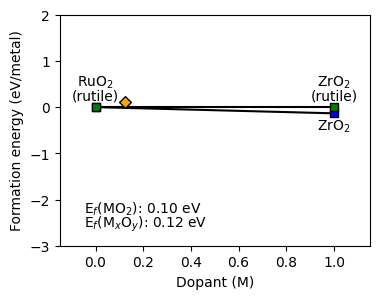

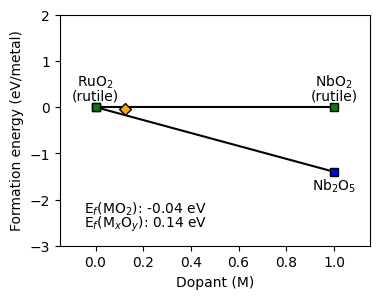

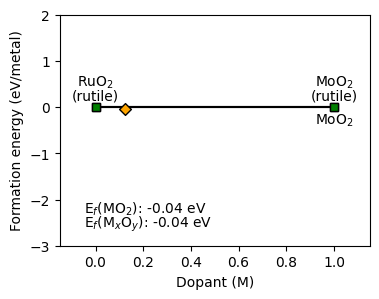

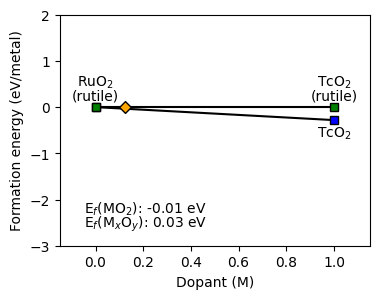

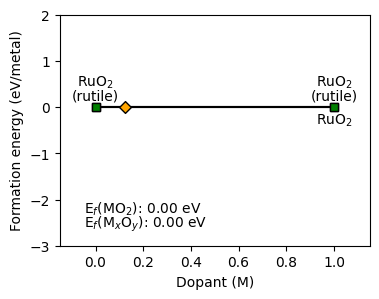

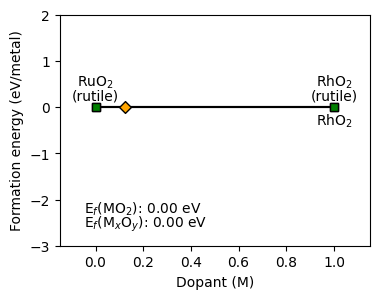

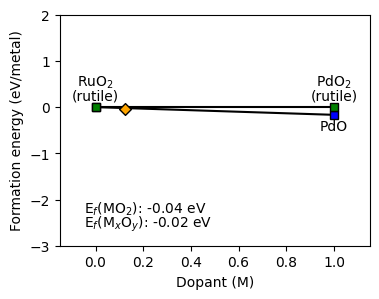

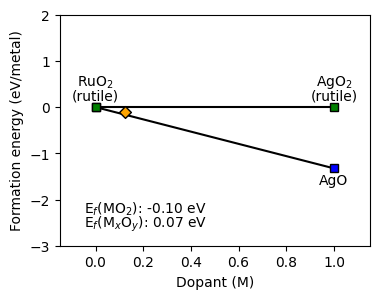

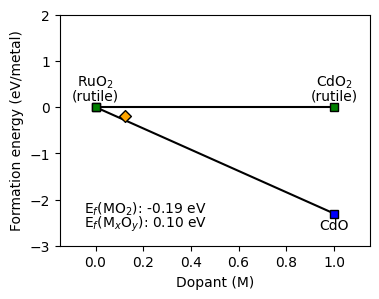

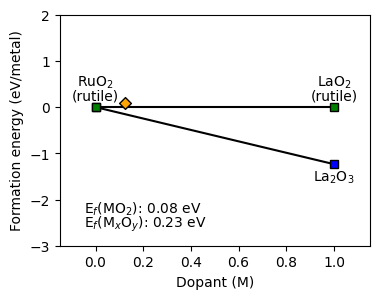

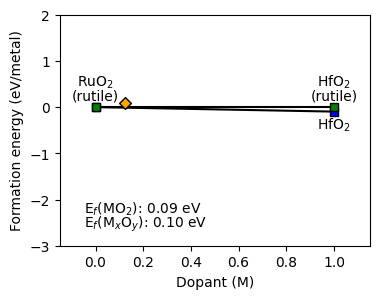

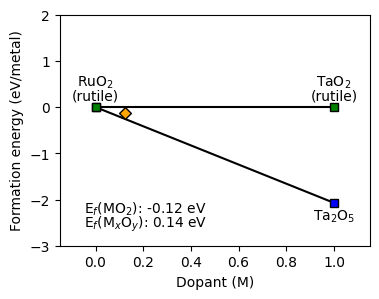

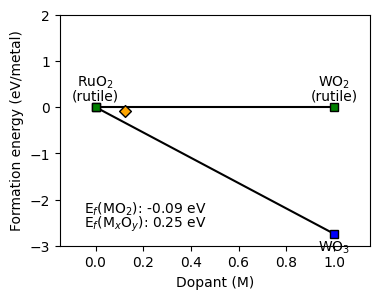

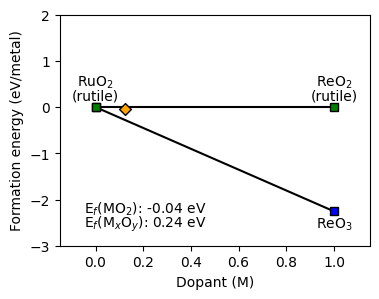

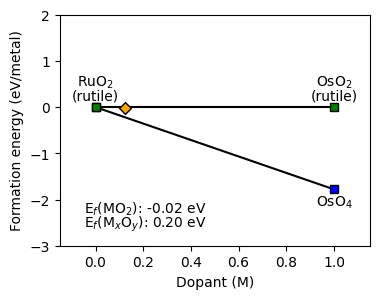

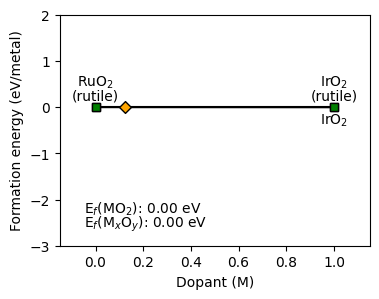

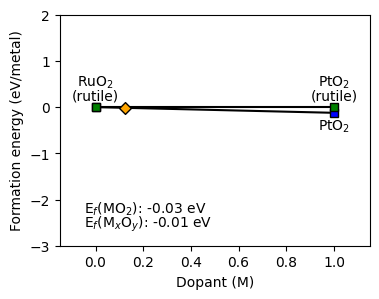

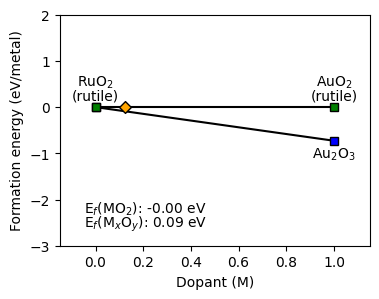

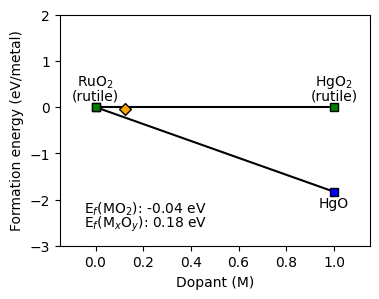

In [53]:

for i in element_indices:
    element = md.element(i).symbol
    m_ratio, o_ratio = int(data.loc[element, 'MxOy_x']), int(data.loc[element, 'MxOy_y'])
    if m_ratio == 1 and o_ratio == 1:
        formula = f'{element}O'
    elif m_ratio == 1:
        formula = f'{element}O$_{o_ratio}$'
    else:
        formula = f'{element}$_{m_ratio}$O$_{o_ratio}$'
    
    plt.figure(figsize=(4,3))

    fe2 = data.loc[element, 'M-RuO2_fe2']
    fe3 = data.loc[element, 'M-RuO2_fe3']
    formation_energy_mxoy = 8*(fe2-fe3)
    plt.plot([0.0, 1.0], [0.0, formation_energy_mxoy], color='black', marker='s', markeredgecolor='black', markerfacecolor='blue', zorder=1)

    plt.plot([0.0, 1.0], [0.0, 0.0], color='black', marker='s', markeredgecolor='black', markerfacecolor='green', linestyle='-', zorder=1)
    plt.text(0.0, 0.1, 'RuO$_2$\n(rutile)', ha='center', va='bottom', linespacing=0.8)

    plt.scatter(1/8, fe2, marker='D', edgecolor='black', facecolor='orange', zorder=2)
    plt.text(-0.05, -2, f'E$_f$(MO$_2$): {fe2:.2f} eV\nE$_f$(M$_x$O$_y$): {fe3:.2f} eV', ha='left', va='top', linespacing=0.8)
    # plt.text(1/8+0.02, formation_energy_mxoy/16+formation_energy_mruo2/2-0.02, f'+{-formation_energy_mxoy/8+formation_energy_mruo2:.2f} eV', ha='left', va='center', color='red')
    if  formation_energy_mxoy > 0:
        plt.text(1.0, formation_energy_mxoy+0.1, f'{formula}', ha='center', va='bottom')
        plt.text(1.0, -0.1, f'{element}O$_2$\n(rutile)', ha='center', va='top', linespacing=0.8)
    else:
        plt.text(1.0, formation_energy_mxoy-0.1, f'{formula}', ha='center', va='top')
        plt.text(1.0, 0.1, f'{element}O$_2$\n(rutile)', ha='center', va='bottom', linespacing=0.8)

    # print(formation_energy_mxoy, formation_energy_mruo2)
    plt.xlim(-0.15, 1.15)
    plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.ylim(-3.0, 2.0)
    plt.xlabel('Dopant (M)')
    plt.ylabel('Formation energy (eV/metal)')
    plt.savefig(f'{root}/figures/bulk_convex_hull_{element}.png', dpi=dpi, transparent=True, bbox_inches='tight')
    plt.show()
    plt.close()
    